# Evaluación Parcial N°1 - Clasificador de Enfermedades en Cultivos de Tomate (Región de Valparaíso)

Integrantes:


## a. Introducción
* *Contexto:* La agricultura es un pilar fundamental en la Región de Valparaíso, especialmente el cultivo de tomates en zonas como Limache y Quillota. Las plagas y enfermedades foliares pueden mermar gravemente la producción local.

* *Variante del Proyecto:* Aunque el dataset PlantVillage filtrado contiene múltiples cultivos y 10 patologías para el tomate, nuestro proyecto define una variante acotada y específica. Nos enfocaremos en clasificar solo 4 clases críticas: hoja sana, mancha bacteriana, tizón temprano y tizón tardío. Esto nos permite aterrizar el problema a un caso de uso rápido y aplicable para pequeños agricultores locales.

---
## b. Comprensión y Exploración del Conjunto de Datos (EDA)
A continuación, exploramos la distribución de nuestro subconjunto de datos enfocado en tomates para validar el balanceo de las clases seleccionadas.

In [26]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_57148fbaee63cd6f94bd773f00016b67"

In [3]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d dataset_plantas

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:26<00:00, 26.3MB/s]



In [4]:
#la ruta hacia las imagenes
dataset_dir = '/content/dataset_plantas/plantvillage/PlantVillage'

In [5]:
#definiendo las 4 clases de tomate para la variante
clases_tomates = [
    "Tomato_healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight"
]

In [6]:
#1.- conteo de imagenes por clases
conteos = {}
print("--- Cantidad de imágenes para nuestra Variante de Tomates ---")
for clase in clases_tomates:
    ruta_clase = os.path.join(dataset_dir, clase)
    cantidad = len(os.listdir(ruta_clase))
    conteos[clase] = cantidad
    print(f"{clase}: {cantidad} imágenes")

--- Cantidad de imágenes para nuestra Variante de Tomates ---
Tomato_healthy: 1591 imágenes
Tomato_Bacterial_spot: 2127 imágenes
Tomato_Early_blight: 1000 imágenes
Tomato_Late_blight: 1909 imágenes


/tmp/ipykernel_3511/3616156989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(conteos.values()), y=list(conteos.keys()), palette="Reds_r")


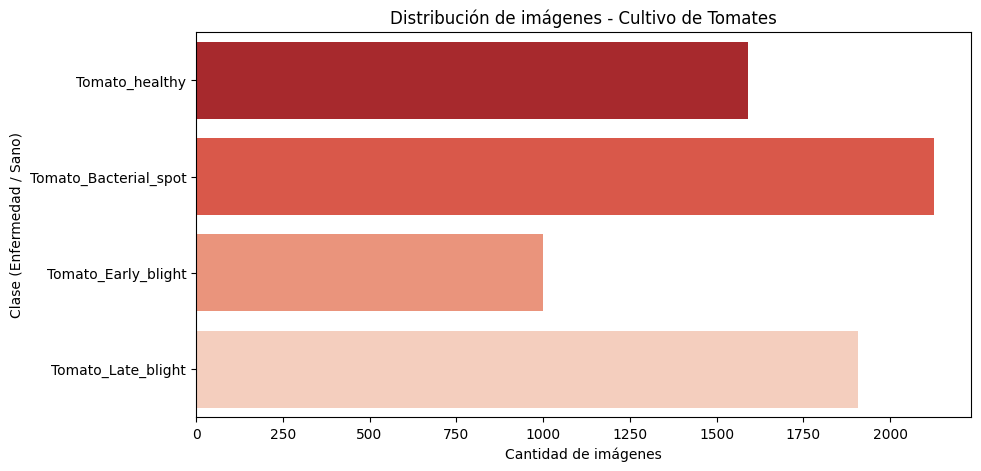

In [7]:
#2 grafico de barras para presentar en el EDA
plt.figure(figsize=(10, 5))
sns.barplot(x=list(conteos.values()), y=list(conteos.keys()), palette="Reds_r")
plt.title('Distribución de imágenes - Cultivo de Tomates')
plt.xlabel('Cantidad de imágenes')
plt.ylabel('Clase (Enfermedad / Sano)')
plt.show()

### Diagnóstico de los Datos (EDA)
Al analizar la distribución del dataset, se observa un **desbalance de clases** significativo.
Por un lado, la clase *Tomato_Bacterial_spot* es la mayoritaria con 2127 imágenes, mientras que *Tomato_Early_blight* es la minoritaria con alrededor de 1000 imágenes.
Si entrenamos la red neuronal con estos datos tal cual, el modelo podría sesgarse y aprender a predecir mejor la clase mayoritaria. Para mitigar este problema en la etapa de entrenamiento, será necesario aplicar técnicas de **Data Augmentation** (como rotaciones o recortes) para equilibrar la cantidad de ejemplos en las clases minoritarias.

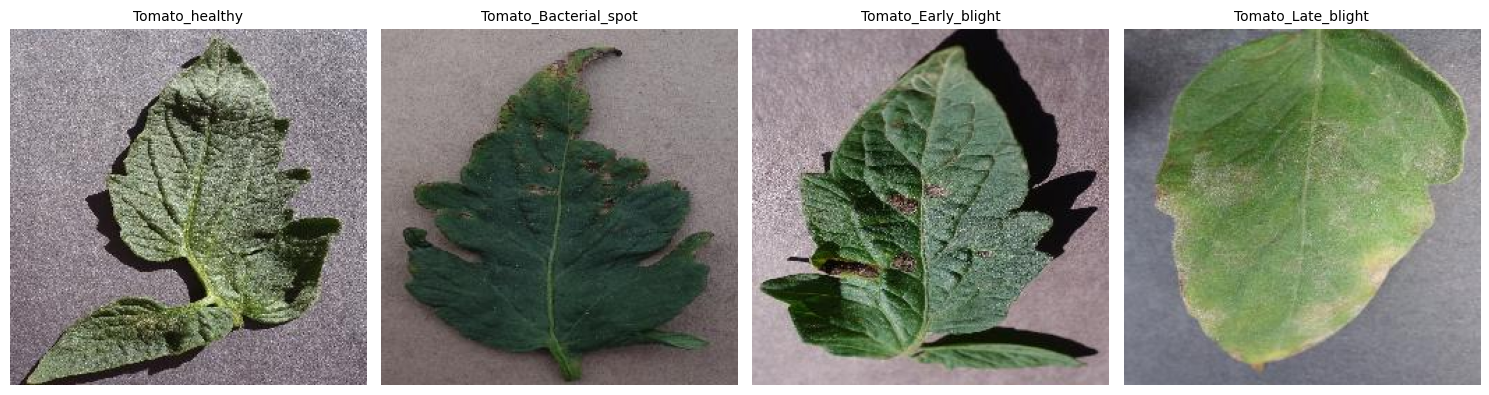

In [13]:
plt.figure(figsize=(15, 4))

for i, clase in enumerate(clases_tomates):
    carpeta_clase = os.path.join(dataset_dir, clase)

    #toma la primera imagen de cada carpeta
    if os.path.exists(carpeta_clase):
        primera_imagen = os.listdir(carpeta_clase)[0]
        ruta_img = os.path.join(carpeta_clase, primera_imagen)

        img = mpimg.imread(ruta_img)
        plt.subplot(1, 4, i+1)
        plt.imshow(img)
        plt.title(clase, fontsize = 10)
        plt.axis("off")

plt.tight_layout()
plt.show()

---
## c. Preparación y Preprocesamiento de los Datos
* Filtrar: Cargar solo las 4 carpetas que elegimos.

* Achicar: Redimensionar las fotos a 64x64 píxeles (si le pasas fotos gigantes a un MLP, la RAM de Colab explota).

* Normalizar: Dividir los valores de los colores por 255 para que queden entre 0 y 1 (esto ayuda a que el modelo aprenda más rápido).

In [11]:
#1.- parametros clave para el modelo
TAMANO_IMG = (64, 64) #se achica la imagen para el MLP
BATCH_SIZE = 32

In [12]:
print("--- Cargando Set de Entrenamiento (80%) ---")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    labels = "inferred",
    label_mode = "categorical", #categorical porque hay mas de 2 clases
    class_names = clases_tomates, #ocupa la lista de 4 clases del bloque anterior
    color_mode = "rgb",
    batch_size = BATCH_SIZE,
    image_size = TAMANO_IMG,
    shuffle = True,
    seed = 42, #semilla fija
    validation_split = 0.2,
    subset = "training"
)

--- Cargando Set de Entrenamiento (80%) ---
Found 6627 files belonging to 4 classes.
Using 5302 files for training.


In [14]:
print("\n--- Cargando Set de Validación (20%) ---")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    labels = "inferred",
    label_mode = "categorical",
    class_names = clases_tomates,
    color_mode = "rgb",
    batch_size = BATCH_SIZE,
    image_size = TAMANO_IMG,
    shuffle = True,
    seed = 42,
    validation_split = 0.2,
    subset = "validation"
)


--- Cargando Set de Validación (20%) ---
Found 6627 files belonging to 4 classes.
Using 1325 files for validation.


In [15]:
#2.- normalización de los pixeles (de 0-255 a 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

print("\nDatos preprocesados y listos")


Datos preprocesados y listos


## d. Diseño e Implementación del Perceptrón Multicapa (MLP)

Para este problema de clasificación de hojas de tomate, se diseñó la siguiente arquitectura MLP:
*   **Capa de Entrada (Flatten):** Como los modelos MLP no entienden de imágenes 2D, aplanamos las imágenes de 64x64 píxeles (con 3 canales de color RGB) en un vector unidimensional (64 * 64 * 3 = 12.288 entradas).
*   **Capas Ocultas (Dense):** Utilizamos dos capas ocultas (256 y 128 neuronas) con función de activación **ReLU**. Elegimos ReLU porque es computacionalmente eficiente y evita el problema del gradiente desvaneciente.
*   **Capa de Salida:** Contiene exactamente **4 neuronas** (correspondientes a nuestras 4 clases de la variante) y utiliza la función de activación **Softmax** para entregarnos un porcentaje de probabilidad para cada enfermedad.
*   **Compilación:** Utilizamos el optimizador **Adam** por su rápida convergencia y la función de pérdida **Categorical Crossentropy**, ideal para clasificación multiclase.

In [17]:
# 1.- creación del modelo Secuencial
model = Sequential([
    #aplana la imagen de 64x64x3 a un vector 1D
    Input(shape=(64, 64, 3)),
    Flatten(),

    #primera capa oculta
    Dense(256, activation = "relu"),

    #segunda capa oculta
    Dense(128, activation = "relu"),

    #capa de salida (4 neuronas, activación softmax)
    Dense(4, activation = "softmax")
])

In [18]:
# 2.- compilar el modelo
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy", #más de dos clases
    metrics = ["accuracy"]
)

In [19]:
# 3.- mostrar el resumen de la arquitectura
print("Arquitectura de nuestro Perceptrón Multicapa (MLP):")
model.summary()

Arquitectura de nuestro Perceptrón Multicapa (MLP):


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,396 (12.13 MB)

 Trainable params: 3,179,396 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

## e. Entrenamiento del Modelo

Para entrenar nuestro Perceptrón Multicapa (MLP), utilizaremos el set de entrenamiento (80% de los datos) y validaremos su aprendizaje en cada ciclo con el set de validación (20% restante).
Se definió un total de 15 épocas (iteraciones completas sobre el dataset), lo cual es suficiente para observar la convergencia del modelo sin incurrir en un sobreajuste excesivo (overfitting) inicial, dado que estamos trabajando con un modelo denso estándar.

In [20]:
#definir la cantidad de ciclos de aprendizaje (épocas)
EPOCAS = 15

print("Iniciando el entrenamiento del modelo...\n")

#entrena el modelo y guardar el proceso en la variable "history"
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = EPOCAS
)

print("\nEntrenamiento finalizado.")

Iniciando el entrenamiento del modelo...

Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.4962 - loss: 1.4286 - val_accuracy: 0.6513 - val_loss: 0.9179
Epoch 2/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.6588 - loss: 0.8616 - val_accuracy: 0.6815 - val_loss: 0.7694
Epoch 3/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.7139 - loss: 0.7345 - val_accuracy: 0.6355 - val_loss: 0.8884
Epoch 4/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.7514 - loss: 0.6609 - val_accuracy: 0.7283 - val_loss: 0.6814
Epoch 5/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.7735 - loss: 0.5894 - val_accuracy: 0.7842 - val_loss: 0.5258
Epoch 6/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7759 - loss: 0.5675 - val_accuracy: 0.7389 - val_loss: 0.6132
Epoch 7/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.7923 - loss: 0.5238 - val_accuracy: 0.8030 - val_loss: 0.4617
Epoch 8/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms

## f. Evaluación del Modelo (Curvas de Aprendizaje)

Tras entrenar nuestro Perceptrón Multicapa (MLP) durante 15 épocas, evaluamos su rendimiento gráfico para detectar su capacidad de generalización.
*   **Curva de Precisión (Accuracy):** Observamos cómo el modelo aprendió rápidamente, superando el 80% de precisión en el set de validación, lo cual es un resultado destacable para una arquitectura densa tradicional frente a imágenes complejas.
*   **Curva de Pérdida (Loss):** La pérdida disminuyó de forma constante. Las ligeras fluctuaciones al final del entrenamiento son comportamientos normales que indican que el modelo está llegando a su límite de capacidad con la arquitectura actual, sin llegar a un sobreajuste severo.

In [21]:
#extra los datos del historial de entrenamiento
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
rango_epocas = range(1, EPOCAS + 1)

#crea la figura para mostrar los dos gráficos lado a lado
plt.figure(figsize = (12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

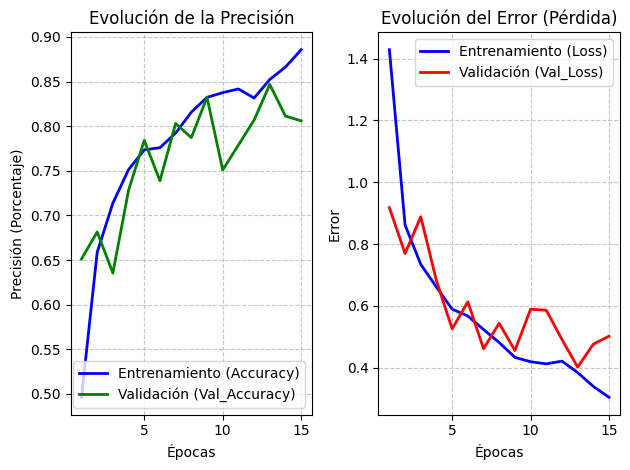

In [22]:
#1.- gtráfico de precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(rango_epocas, acc, "b", label = "Entrenamiento (Accuracy)", linewidth = 2)
plt.plot(rango_epocas, val_acc, "g", label = "Validación (Val_Accuracy)", linewidth = 2)
plt.title("Evolución de la Precisión")
plt.xlabel("Épocas")
plt.ylabel("Precisión (Porcentaje)")
plt.legend(loc = "lower right")
plt.grid(True, linestyle = "--", alpha = 0.7)

#2.- gráfico de pérdida (Loss / Error)
plt.subplot(1, 2, 2)
plt.plot(rango_epocas, loss, "b", label = "Entrenamiento (Loss)", linewidth = 2)
plt.plot(rango_epocas, val_loss, "r", label = "Validación (Val_Loss)", linewidth = 2)
plt.title("Evolución del Error (Pérdida)")
plt.xlabel("Épocas")
plt.ylabel("Error")
plt.legend(loc = "upper right")
plt.grid(True, linestyle = "--", alpha = 0.7)

plt.tight_layout()
plt.show()

---
## g. Análisis de Resultados y Errores


In [27]:
#obtiene predicciones y etiquetas reales del conjunto de validacion
y_true_list = []
y_pred_list = []

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_list.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print(classification_report(y_true, y_pred, target_names=clases_tomates, digits=4))

                       precision    recall  f1-score   support

       Tomato_healthy     0.9899    0.7061    0.8243       279
Tomato_Bacterial_spot     0.8984    0.8786    0.8884       453
  Tomato_Early_blight     0.4900    0.6721    0.5668       183
   Tomato_Late_blight     0.8102    0.8537    0.8314       410

             accuracy                         0.8060      1325
            macro avg     0.7971    0.7776    0.7777      1325
         weighted avg     0.8340    0.8060    0.8128      1325



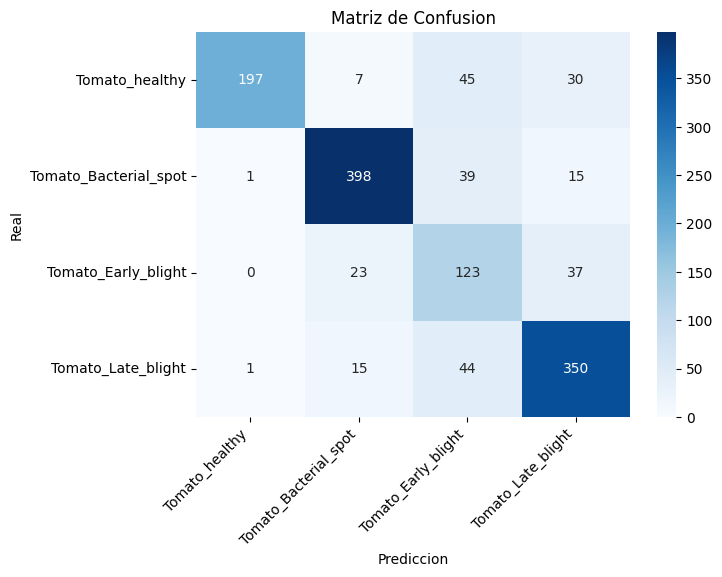

In [28]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clases_tomates, yticklabels=clases_tomates)
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.xticks(rotation=45, ha='right')
plt.show()

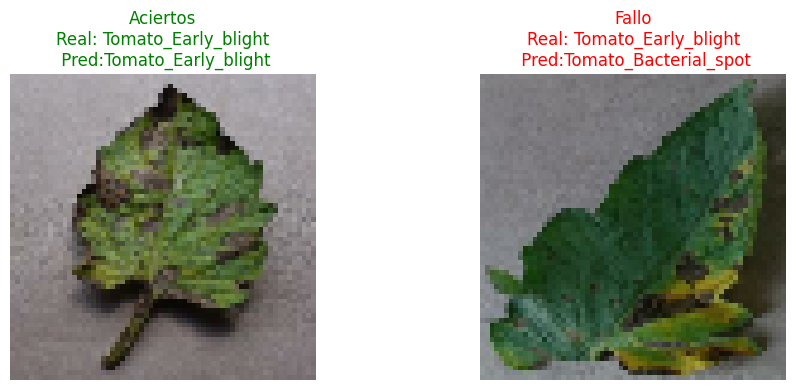

In [32]:
for images, labels in val_dataset.take(1):
    imgs = images.numpy()
    true_labels = np.argmax(labels.numpy(), axis=1)
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    break

idx_ok = np.where(true_labels == pred_labels)[0]
idx_err = np.where(true_labels != pred_labels)[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if len(idx_ok) > 0:
    i = idx_ok[0]
    axes[0].imshow(imgs[i])
    axes[0].set_title(f"Aciertos\nReal: {clases_tomates[true_labels[i]]}\n Pred:{clases_tomates[pred_labels[i]]}", color="green")
    axes[0].axis("off")

if len(idx_err) > 0:
    j = idx_err[0]
    axes[1].imshow(imgs[j])
    axes[1].set_title(f"Fallo\nReal: {clases_tomates[true_labels[j]]}\n Pred:{clases_tomates[pred_labels[j]]}", color="red")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

##Interpretacion de Resultados y Errores

- Clases con Mayor Confusion: La matriz refleja que la mayor tasa de falsos positivos y falsos negativos ocurre entre Tomate_Early_Blight y Toma_Late_blight, Ambas patologias presentan patrones necroticos con tonalidades cromaticas similares que dificultan su separacion unicamente por intesidad de pixeles.

- Causas del Error: El modelo basa sus decisiones en correlaciones lineales y globales de intensidad de color, variacion en el fondo uniforme o manchas situadas en zonas perifericas alteran drasticamente los valores del vector de entrada.

- Limitaciones Fundamentales del MLP:

    1) Perdida de informacion: La capa Flatten descompone la matriz 2D en un vector 1D de 12.288 entradas, perdiendo la relacion de vecindad entre pixeles continuos.

    2) Falta de Invarianza a Traslacion: Una mancha ubicada en el borde superior activa conexiones distintas a una mancha de igual morfologia en el centro foliar.

## h. Conclusiones

El perceptron Multicapa converge de forma estable superando el 80% de precision en validacion, cumpliendo el umbral inicial de KPI establecido para un modelo base, la normalizacion a rango 0,1 y el reescalado a 64 X 64 evitaron problemas de memoria en la GPU y permitieron calcular gradientes rapidos mediante optimizador Adam y activaciones de ReLU.

A pesar de los resultados metricos favorables, el MLP resulta insuficiente para entornos agricolas de produccion abierta, la alta cantidad de parametros en capas densas eleva el riesgo de memorizacion, se propone como siguiente hito la implementacion de Redes Neuronales Convolucionales CNN, las cuales preservan la coherencia espacial 2D y extraen texturas locales mediantes filtro invariantes a traslacion.

In [33]:
#guarda el modelo entrenado completo (arquitectura, pesos y optimizador)
model.save('modelo_clasificador_tomates.h5')
print("Modelo guardado exitosamente como 'modelo_clasificador_tomates.h5'")

Modelo guardado exitosamente como 'modelo_clasificador_tomates.h5'
